In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import torch.nn.functional as F

# Maze Construction

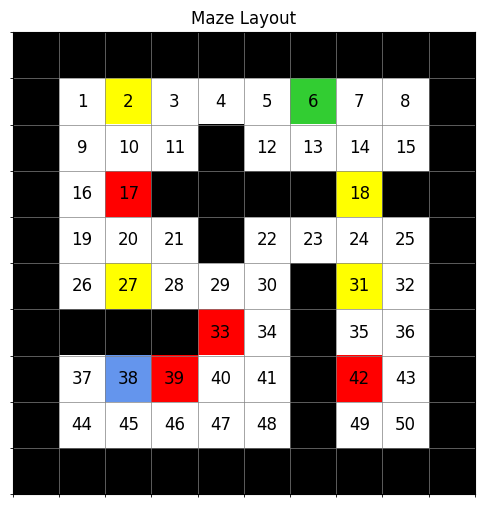

In [ ]:
reward = np.zeros((10,10))
wall,bump,oil,goal,start = -0.8,-10,-5,100,0
reward[:,0]=reward[0,:]=reward[:,9]=reward[9,:]=wall
reward[1,2], reward[1,6] = oil, goal
reward[2,4] = wall
reward[3,2]=bump; reward[3,3:7]=wall; reward[3,7]=oil; reward[3,8]=wall
reward[4,4]=wall
reward[5,2]=oil; reward[5,6]=wall; reward[5,7]=oil
reward[6,1:4]=wall; reward[6,4]=bump; reward[6,6]=wall
reward[7,2]=start; reward[7,3]=bump; reward[7,6]=wall; reward[7,7]=bump
reward[8,6]=wall

state_matrix = np.zeros((10,10),dtype=int)
cnt=1
for i in range(10):
    for j in range(10):
        if reward[i,j]!=wall:
            state_matrix[i,j]=cnt
            cnt+=1

mapped_maze = np.zeros_like(reward)
mapped_maze[reward==wall] = 1
mapped_maze[reward==bump] = 2
mapped_maze[reward==oil ] = 3
mapped_maze[reward==goal] = 4
mapped_maze[7,2]         = 5

cmap_vis = plt.matplotlib.colors.ListedColormap(
    ["white","black","red","yellow","limegreen","cornflowerblue"]
)

# ─────── Plot Maze Layout ──────────
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(mapped_maze, cmap=cmap_vis, origin="upper")
ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
ax.set_xticks([]); ax.set_yticks([])

for s in np.nditer(state_matrix[state_matrix!=0]):
    i,j = np.where(state_matrix==s)
    i,j = i[0], j[0]
    ax.text(j, i, str(int(s)),
            ha="center", va="center",
            color="black", fontsize=12)
ax.set_title("Maze Layout")
plt.show()

Movements in The Maze

In [79]:
def next_state(s,a,p=0.025):
    row,col = np.where(state_matrix==s)
    row,col = row[0],col[0]
    moves = {
      "U":[(-1,0),(0,-1),(0,1)],
      "D":[(1,0),(0,-1),(0,1)],
      "R":[(0,1),(-1,0),(1,0)],
      "L":[(0,-1),(-1,0),(1,0)]
    }
    probs = [1-p, p/2, p/2]
    dr,dc = moves[a][np.random.choice(3,p=probs)]
    i2,j2 = row+dr, col+dc
    R = reward[i2,j2] - 1
    if reward[i2,j2]==wall:
        return R, state_matrix[row,col]

    return R, state_matrix[i2,j2]

Create Maze Environment

In [80]:
class MazeEnv:
    def __init__(self,p=0.025,max_steps=50):
        self.p,self.max_steps = p,max_steps
        self.steps = 0
    def reset(self):
        self.steps=0
        valid = np.argwhere((reward!=wall)&(reward!=goal))
        i,j = valid[random.randrange(len(valid))]
        self.state = state_matrix[i,j]
        return np.array([i,j],dtype=np.float32)
    def step(self,action_idx):
        self.steps+=1
        a = actions[action_idx]
        R,s2 = next_state(self.state,a,self.p)
        self.state = s2
        i,j = np.where(state_matrix==s2)
        done = bool((reward[i,j]==goal))
        return np.array([i[0],j[0]],dtype=np.float32), R, done


# Plotting Functions

In [81]:
def plot_policy(policy,title="Optimal Policy"):
    fig,ax = plt.subplots(figsize=(7,7))
    ax.imshow(mapped_maze,cmap=cmap_vis,origin="upper")
    ax.set_xticks(np.arange(-0.5,10,1),minor=True)
    ax.set_yticks(np.arange(-0.5,10,1),minor=True)
    ax.grid(which="minor",color="gray",linestyle='-',linewidth=0.5)
    ax.set_xticks([]); ax.set_yticks([])

    for s in np.nditer(state_matrix):
        if s==0: continue
        i,j = np.where(state_matrix==s)
        i,j = i[0],j[0]
        a = policy[s-1]
        if not a: continue
        dx,dy = {"U":(0,-0.3),"D":(0,0.3),"L":(-0.3,0),"R":(0.3,0)}[a]
        ax.arrow(j,i,dx,dy,head_width=0.1,head_length=0.1,color='black')

    ax.set_title(title)
    plt.show()

def get_optimal_policy(agent):
    S = state_matrix.max()
    pol = ['']*S
    mapping={0:'U',1:'D',2:'L',3:'R'}
    for s in range(1,S+1):
        pos = np.where(state_matrix==s)
        if pos[0].size==0: continue
        i,j = pos[0][0],pos[1][0]
        if reward[i,j]==goal: continue
        st = torch.FloatTensor([i,j]).unsqueeze(0).to(agent.device)
        with torch.no_grad():
            qv = agent.qnet(st)
        pol[s-1] = mapping[int(qv.argmax())]
    return pol

def simulate_from_start(agent):
    env = MazeEnv()
    env.state = state_matrix[7,2]    # fixed blue start
    pos = np.array([7,2],dtype=np.float32)
    path=[(7,2)]
    done=False; steps=0
    while not done and steps<max_ep:
        a = agent.select_action(pos,0.0)
        pos,_,done = env.step(a)
        path.append((int(pos[0]),int(pos[1])))
        steps+=1
    return np.array(path)

# Replay Memory

In [82]:
class ReplayMemory:
    def __init__(self,capacity=5000):
        self.mem = deque(maxlen=capacity)
    def push(self,trans):
        self.mem.append(trans)
    def sample(self,bsz):
        return random.sample(self.mem,bsz)
    def __len__(self):
        return len(self.mem)

# DQN
Hyperparameters

In [87]:
actions = ["U","D","L","R"]
max_ep = 50
batch_size = 64
alpha = 0.01
gamma = 0.975
eta = 0.005
episodes = 2000
epsilon = 0.995
N_QU = 3

Neural Network

In [88]:

class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,128)
        self.layer2 = nn.Linear(128,128)
        self.layer3 = nn.Linear(128,128)
        self.layer4 = nn.Linear(128,4)
    def forward(self,x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        q = self.layer4(x)
        is_goal = (x[:,0]==1) & (x[:,1]==6)      # boolean mask
        if is_goal.any():
            q[is_goal] = 0.0
        return q

DQN Agent

In [89]:
class DQNAgent:
    def __init__(self,device='cpu'):
        self.device = device
        self.qnet    = DQN().to(device)
        self.target  = DQN().to(device)
        self.target.load_state_dict(self.qnet.state_dict())
        self.opt     = optim.Adam(self.qnet.parameters(),lr=alpha)
        self.memory  = ReplayMemory(5000)

    def select_action(self,state,eps):
        if random.random()<eps:
            return random.randrange(4)
        st = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            qv = self.qnet(st)
        return int(qv.argmax())

    def store_transition(self,trans):
        self.memory.push(trans)

    def update(self):
        if len(self.memory)<2*batch_size:
            return 0.0

        batch = self.memory.sample(batch_size)
        # stack once, then convert
        states_np      = np.stack([t[0] for t in batch]).astype(np.float32)
        next_states_np = np.stack([t[3] for t in batch]).astype(np.float32)

        states      = torch.from_numpy(states_np).to(self.device)
        actions     = torch.LongTensor([t[1] for t in batch]).unsqueeze(1).to(self.device)
        rewards     = torch.FloatTensor([t[2] for t in batch]).unsqueeze(1).to(self.device)
        next_states = torch.from_numpy(next_states_np).to(self.device)
        dones       = torch.FloatTensor([float(t[4]) for t in batch]).unsqueeze(1).to(self.device)

        Q   = self.qnet(states).gather(1,actions)
        Qn  = self.target(next_states).max(1,keepdim=True)[0]
        Y   = rewards + gamma*Qn*(1-dones)

        loss = F.mse_loss(Q,Y,reduction='sum')
        self.opt.zero_grad(); loss.backward(); self.opt.step()

        # soft‐update
        for tgt,src in zip(self.target.parameters(),self.qnet.parameters()):
            tgt.data.copy_(eta*src.data + (1-eta)*tgt.data)

        return loss.item()

# Training and Optimal Path

Ep 1000/2000  R=63.0  L=269.3
Ep 2000/2000  R=88.0  L=1286.9


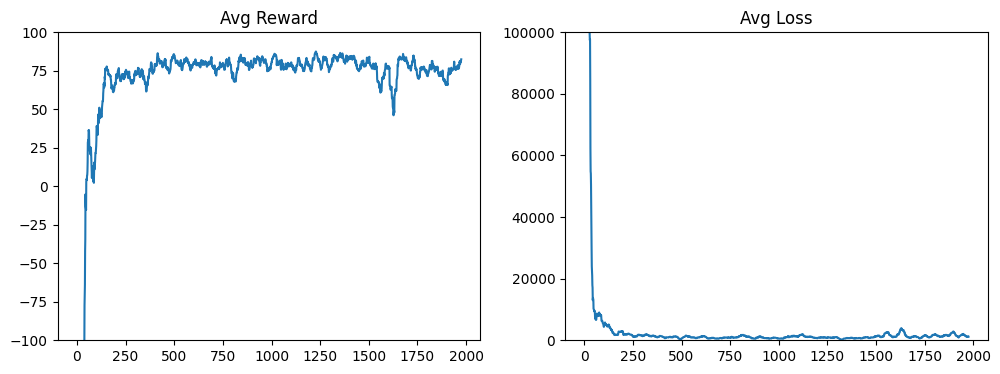

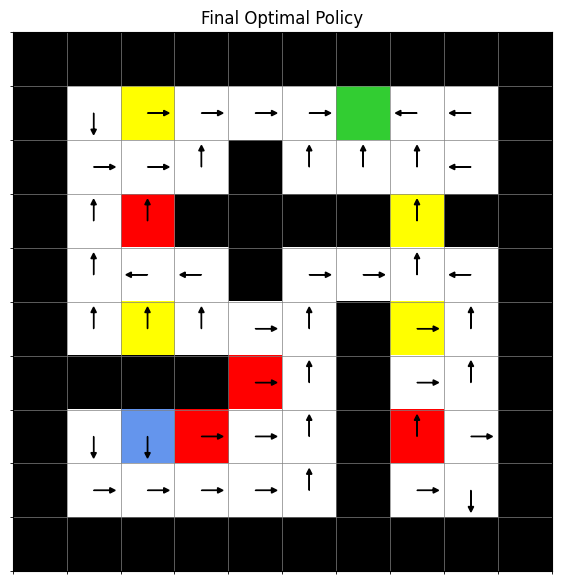

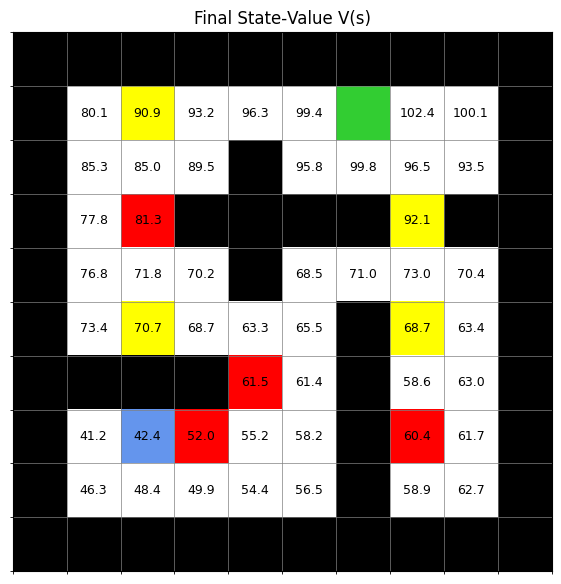

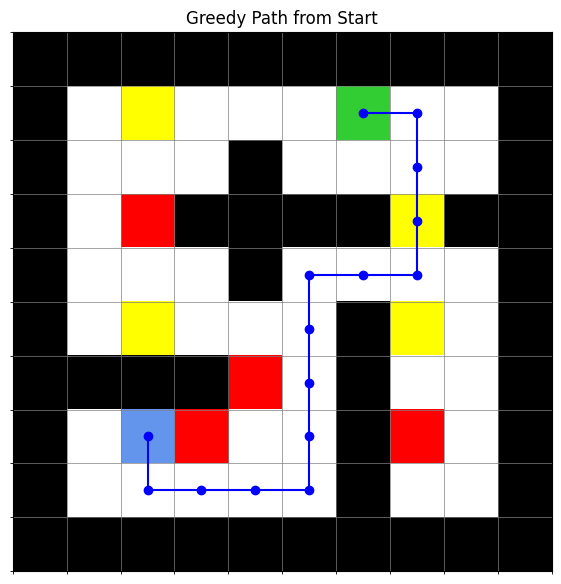

In [93]:

def train_and_plot(agent,env):
    epi_R, epi_L = [],[]
    for ep in range(episodes):
        state   = env.reset()
        tot_R   = 0.0
        tot_L   = 0.0
        step_ct = 0
        done    = False
        eps_cur = max(0.1, epsilon**ep)
        while not done:
            a = agent.select_action(state,eps_cur)
            ns,r,done = env.step(a)
            agent.store_transition((state,a,r,ns,done))
            state = ns
            tot_R += r
            step_ct += 1
            if step_ct % N_QU == 0:
                tot_L += agent.update()
        epi_R.append(tot_R); epi_L.append(tot_L)

        if (ep+1)%1000==0:
            print(f"Ep {ep+1}/{episodes}  R={tot_R:.1f}  L={tot_L:.1f}")

    # moving averages
    ma = lambda x,n=25: np.convolve(x,np.ones(n)/n,mode='valid')
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(ma(epi_R)); plt.title("Avg Reward"); plt.ylim(-100, 100)
    plt.subplot(1,2,2); plt.plot(ma(epi_L)); plt.title("Avg Loss"); plt.ylim(0, 100000)
    plt.show()

    # plot final policy
    pol = get_optimal_policy(agent)
    plot_policy(pol,"Final Optimal Policy")

    # plot numeric V(s)
    S = state_matrix.max()
    vals = np.zeros(S)
    with torch.no_grad():
        for s in range(1,S+1):
            pos = np.where(state_matrix==s)
            if pos[0].size==0: continue
            i,j = pos[0][0],pos[1][0]
            qv = agent.qnet(torch.FloatTensor([i,j]).unsqueeze(0).to(agent.device))
            vals[s-1] = float(qv.max())

    fig,ax = plt.subplots(figsize=(7,7))
    ax.imshow(mapped_maze,cmap=cmap_vis,origin="upper")
    ax.set_xticks(np.arange(-0.5,10,1),minor=True)
    ax.set_yticks(np.arange(-0.5,10,1),minor=True)
    ax.grid(which="minor",color="gray",linestyle='-',linewidth=0.5)
    ax.set_xticks([]); ax.set_yticks([])
    for i in range(10):
        for j in range(10):
            sid = state_matrix[i,j]
            if (sid>0 and sid!= 6):
                ax.text(j,i,f"{vals[sid-1]:.1f}",
                        ha="center",va="center",
                        color="black",fontsize=9)
    ax.set_title("Final State‑Value V(s)")
    plt.show()

    # plot greedy path from fixed start
    path = simulate_from_start(agent)
    fig,ax = plt.subplots(figsize=(7,7))
    ax.imshow(mapped_maze,cmap=cmap_vis,origin="upper")
    ax.set_xticks(np.arange(-0.5,10,1),minor=True)
    ax.set_yticks(np.arange(-0.5,10,1),minor=True)
    ax.grid(which="minor",color="gray",linestyle='-',linewidth=0.5)
    ax.set_xticks([]); ax.set_yticks([])
    ys,xs = path[:,0], path[:,1]
    ax.plot(xs,ys,marker='o',color='blue')
    ax.set_title("Greedy Path from Start")
    plt.show()

if __name__=="__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env   = MazeEnv()
    agent = DQNAgent(device)
    train_and_plot(agent, env)


# Double DQN
Hyperparameters

In [ ]:
actions = ["U","D","L","R"]
max_ep = 50
batch_size = 64
alpha = 0.01
gamma = 0.975
eta = 0.005
episodes = 2000
epsilon = 0.995
N_QU = 3


Double DQN Agent and Training

Ep 1000/2000  R=88.0  L=1464.6
Ep 2000/2000  R=75.0  L=2109.0


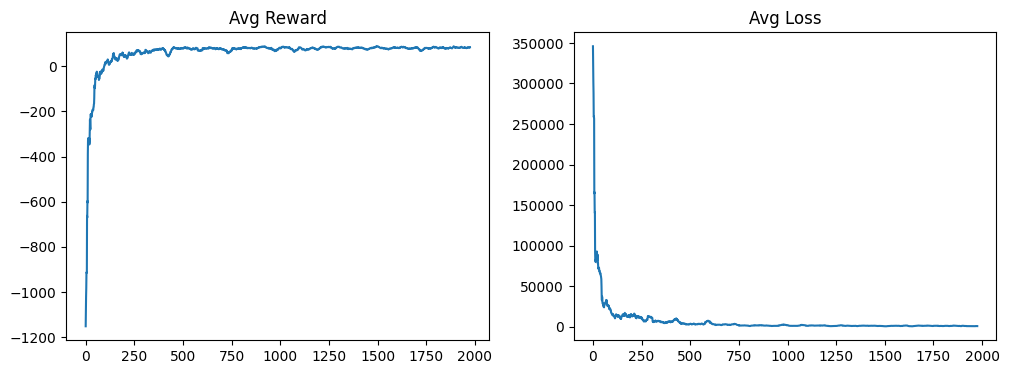

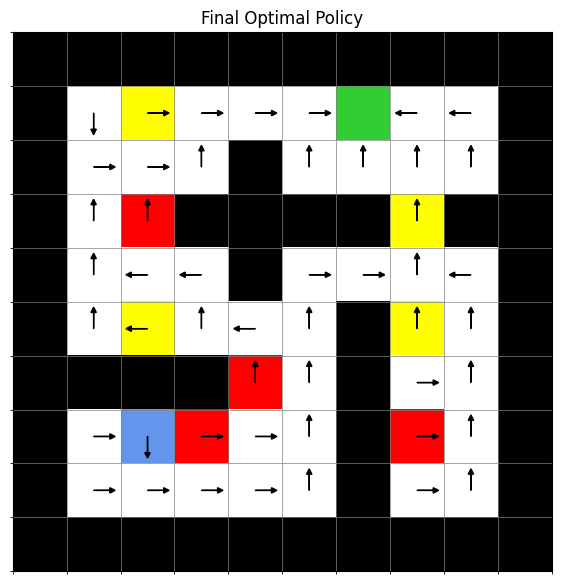

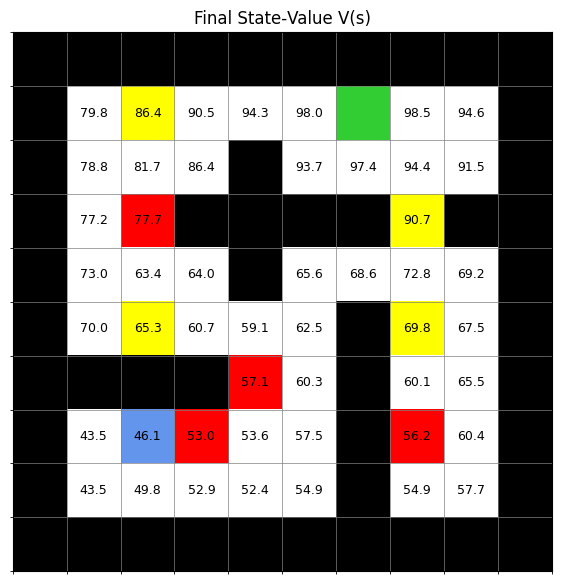

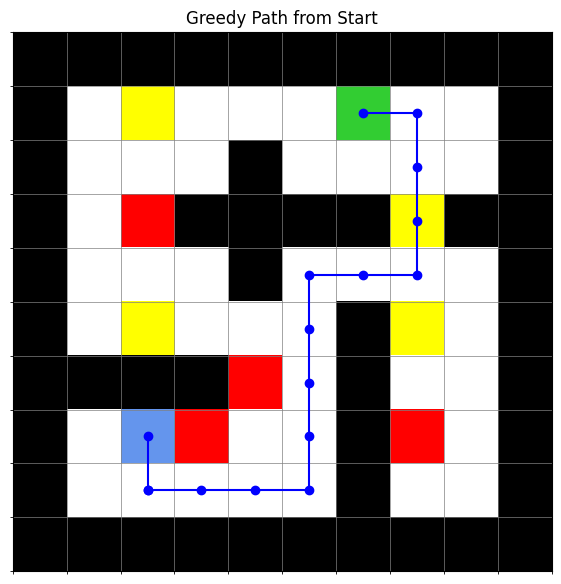

In [ ]:
class DoubleDQNAgent:
    def __init__(self,device='cpu'):
        self.device = device
        self.qnet    = DQN().to(device)
        self.target  = DQN().to(device)
        self.target.load_state_dict(self.qnet.state_dict())
        self.opt     = optim.Adam(self.qnet.parameters(),lr=alpha)
        self.memory  = ReplayMemory(10000)

    def select_action(self,state,eps):
        if random.random()<eps:
            return random.randrange(4)
        st = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            qv = self.qnet(st)
        return int(qv.argmax())

    def store_transition(self,trans):
        self.memory.push(trans)

    def update(self):
        if len(self.memory) < batch_size:
            return 0.0

        batch = self.memory.sample(batch_size)

        states_np      = np.stack([t[0] for t in batch]).astype(np.float32)
        next_states_np = np.stack([t[3] for t in batch]).astype(np.float32)

        states      = torch.from_numpy(states_np).to(self.device)
        actions     = torch.LongTensor([t[1] for t in batch]).unsqueeze(1).to(self.device)
        rewards     = torch.FloatTensor([t[2] for t in batch]).unsqueeze(1).to(self.device)
        next_states = torch.from_numpy(next_states_np).to(self.device)
        dones       = torch.FloatTensor([float(t[4]) for t in batch]).unsqueeze(1).to(self.device)

        # current Q-values
        Q = self.qnet(states).gather(1, actions)

        # online net picks the best next action
        best_next_actions = self.qnet(next_states).argmax(dim=1, keepdim=True)
        # target net evaluates that action
        Qn = self.target(next_states).gather(1, best_next_actions)
        # form target
        Y  = rewards + gamma * Qn * (1 - dones)

        # MSE loss (sum)
        loss = F.mse_loss(Q, Y, reduction='sum')
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # soft‑update target network
        for tgt, src in zip(self.target.parameters(), self.qnet.parameters()):
            tgt.data.copy_(eta * src.data + (1.0 - eta) * tgt.data)

        return loss.item()

    
if __name__=="__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env   = MazeEnv()
    agent = DoubleDQNAgent(device)
    train_and_plot(agent, env)

# Dueling DQN
Hyperparameters

In [97]:
actions = ["U","D","L","R"]
max_ep = 50
batch_size = 64
alpha = 0.01
gamma = 0.975
eta = 0.005
episodes = 1500
epsilon = 0.995
N_QU |= 3

Dueling DQN Neural Network and

In [98]:
class DuelingDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2,   128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 128)
        # value
        self.value_head     = nn.Linear(128, 1)
        # advantage stream
        self.advantage_head = nn.Linear(128, 4)

    def forward(self, x):
        orig = x    
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        feats = F.relu(self.layer3(x)) 

        # compute V(s)
        V = self.value_head(feats)    
        # compute A(s,a)
        A = self.advantage_head(feats)  
        Q = V + (A - A.mean(dim=1, keepdim=True)) 
        is_goal = (orig[:,0] == 1) & (orig[:,1] == 6)
        if is_goal.any():
            Q[is_goal, :] = 0.0

        return Q


Dueling DQN Agent and Training

Ep 1000/1500  R=85.0  L=2988.2


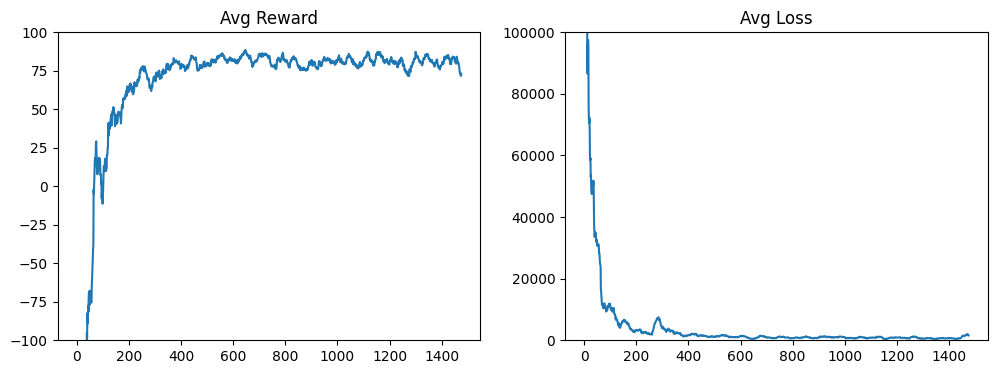

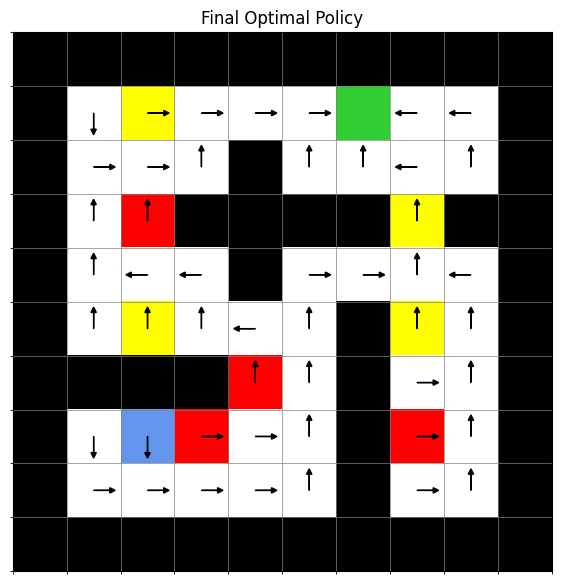

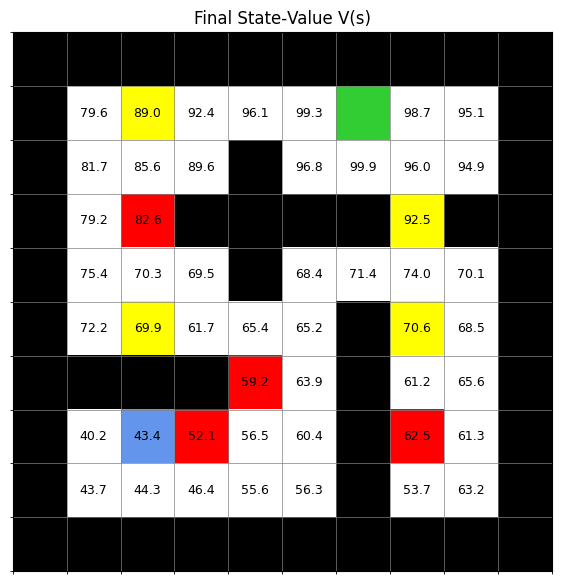

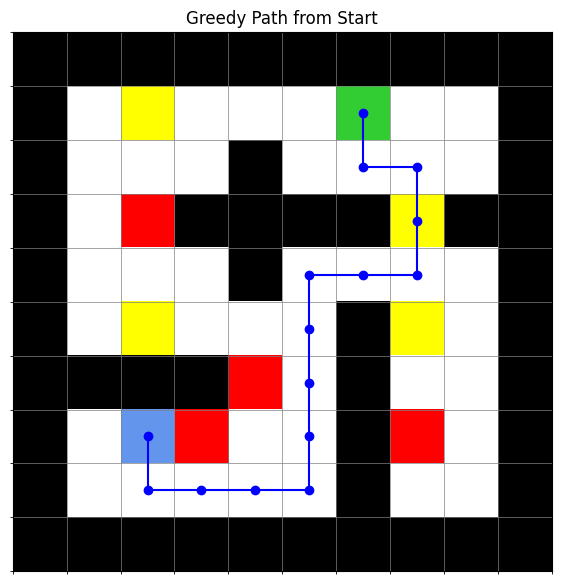

In [102]:


class DuelDQNAgent:
    def __init__(self,device='cpu'):
        self.device = device
        self.qnet    = DuelingDQN().to(device)
        self.target  = DuelingDQN().to(device)
        self.target.load_state_dict(self.qnet.state_dict())
        self.opt     = optim.Adam(self.qnet.parameters(),lr=alpha)
        self.memory  = ReplayMemory(10000)

    def select_action(self,state,eps):
        if random.random()<eps:
            return random.randrange(4)
        st = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            qv = self.qnet(st)
        return int(qv.argmax())

    def store_transition(self,trans):
        self.memory.push(trans)

    def update(self):
        if len(self.memory) < batch_size:
            return 0.0

        batch = self.memory.sample(batch_size)

        # stack & to‐tensor as before
        states_np      = np.stack([t[0] for t in batch]).astype(np.float32)
        next_states_np = np.stack([t[3] for t in batch]).astype(np.float32)

        states      = torch.from_numpy(states_np).to(self.device)
        actions     = torch.LongTensor([t[1] for t in batch]).unsqueeze(1).to(self.device)
        rewards     = torch.FloatTensor([t[2] for t in batch]).unsqueeze(1).to(self.device)
        next_states = torch.from_numpy(next_states_np).to(self.device)
        dones       = torch.FloatTensor([float(t[4]) for t in batch]).unsqueeze(1).to(self.device)

        # current Q-values
        Q = self.qnet(states).gather(1, actions)

        # online net picks the best next action
        best_next_actions = self.qnet(next_states).argmax(dim=1, keepdim=True)
        # target net evaluates that action
        Qn = self.target(next_states).gather(1, best_next_actions)
        # form target
        Y  = rewards + gamma * Qn * (1 - dones)

        # MSE loss (sum)
        loss = F.mse_loss(Q, Y, reduction='sum')
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # soft‑update target network
        for tgt, src in zip(self.target.parameters(), self.qnet.parameters()):
            tgt.data.copy_(eta * src.data + (1.0 - eta) * tgt.data)

        return loss.item()

    
if __name__=="__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env   = MazeEnv()
    agent = DuelDQNAgent(device)
    train_and_plot(agent, env)